Segmenting buildings in aerial imagery using DINOv2.

From terminal:  `uv run jupyter notebook`

Aerial imagery dataset:  https://www.kaggle.com/datasets/aletbm/aerial-imagery-dataset-floodnet-challenge

In [4]:
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import cv2
from transformers import AutoImageProcessor, Dinov2Model

# load pretrained base model
device = "cuda" if torch.cuda.is_available() else "cpu"
model_name = "facebook/dinov2-base"
processor = AutoImageProcessor.from_pretrained(model_name)
model = Dinov2Model.from_pretrained(model_name).to(device)
model.eval()

# load sample image
img_path = "suburb.jpg"
img = Image.open(img_path).convert("RGB")

extract patch features

In [2]:
inputs = processor(images=img, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model(**inputs)

# last_hidden_state: (1, num_tokens, hidden_dim)
tokens = outputs.last_hidden_state  # includes CLS token at index 0
patch_tokens = tokens[:, 1:, :]     # drop CLS

B, N, D = patch_tokens.shape
patch_tokens = patch_tokens[0].cpu().numpy()  # (N, D)

# infer patch grid size (ViT patch layout)
h_patches = inputs.pixel_values.shape[2] // model.config.patch_size
w_patches = inputs.pixel_values.shape[3] // model.config.patch_size
assert h_patches * w_patches == N

cluster patches

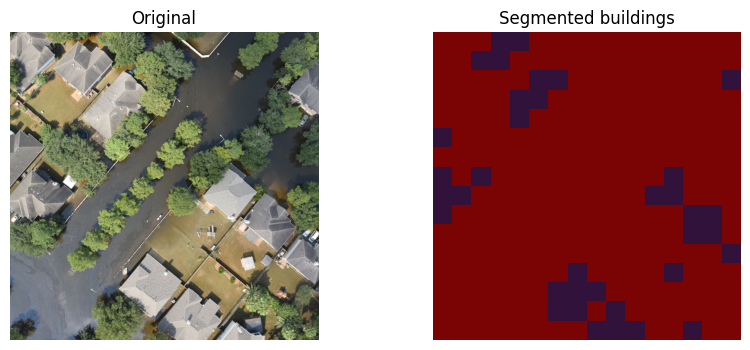

In [ ]:
from sklearn.cluster import KMeans

k = 2  # number of segments
kmeans = KMeans(n_clusters=k, random_state=0, n_init="auto")
labels = kmeans.fit_predict(patch_tokens)  # (N,)

# reshape to patch grid
label_map = labels.reshape(h_patches, w_patches)

# Map labels to colors
label_img = (label_map / (k-1) * 255).astype(np.uint8)
label_img_color = cv2.applyColorMap(label_img, cv2.COLORMAP_TURBO)
label_img_color = cv2.cvtColor(label_img_color, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(img); plt.axis("off"); plt.title("Original")
plt.subplot(1,2,2); plt.imshow(label_img_color); plt.axis("off"); plt.title("Segmented buildings")
plt.show()